# ARV Supply Chain Pricing Intelligence

## tl;dr

This notebook reproduces the dataset audit and decision metrics behind the portfolio dashboard. The dataset contains 10,324 shipment line items from 2006-2015; 8,550 are ARV records. Freight and weight are materially incomplete, so freight benchmarks and modeling use only rows with positive, captured values. The production pipeline records model performance and cost drivers in `data/processed/pricing_intelligence.json`.

## Context & Methods

The analytical grain is one shipment line item. The project separates procurement value, freight cost, and landed cost; it does not treat medication value as revenue.

### Key Assumptions
- A shipment is on time when delivered on or before its scheduled date.
- Freight-per-kilogram requires positive captured freight and weight.
- Historical public-health logistics data demonstrates the workflow but should not be presented as current market pricing.
- Model metrics come from a chronological 80/20 evaluation created by `pipeline.py`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW = ROOT / 'data/raw/Supply_Chain_Shipment_Pricing_Dataset.csv'
MODEL = ROOT / 'data/processed/pricing_intelligence.json'
print('Source:', RAW)

Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories


Fontconfig error: No writable cache directories


Matplotlib is building the font cache; this may take a moment.


Source: /Users/ayushdaga/Documents/Codex/2026-08-24/ai-analyst-portfolio-projects/project_3_arv_pricing_intelligence/data/raw/Supply_Chain_Shipment_Pricing_Dataset.csv


## Data

### 1. Load and normalize the source

In [2]:
df = pd.read_csv(RAW, low_memory=False)
for col in ['line item quantity','line item value','pack price','unit price','weight (kilograms)','freight cost (usd)','line item insurance (usd)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in ['scheduled delivery date','delivered to client date','delivery recorded date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df['year'] = df['delivered to client date'].dt.year
df['delivery_variance_days'] = (df['delivered to client date'] - df['scheduled delivery date']).dt.days
df['on_time'] = df['delivery_variance_days'] <= 0
df['freight_per_kg'] = np.where(df['weight (kilograms)'] > 0, df['freight cost (usd)'] / df['weight (kilograms)'], np.nan)
df.shape

/var/folders/lg/yh729wr56lg9lcyyqkx36j0w0000gn/T/ipykernel_53592/3850469540.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/var/folders/lg/yh729wr56lg9lcyyqkx36j0w0000gn/T/ipykernel_53592/3850469540.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')
/var/folders/lg/yh729wr56lg9lcyyqkx36j0w0000gn/T/ipykernel_53592/3850469540.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


(10324, 37)

### 2. Validate grain, completeness, and domain rules

In [3]:
quality = pd.DataFrame({
    'check': ['Unique IDs','Exact duplicate rows','Missing freight cost','Missing weight','Non-positive item value','Non-positive unit price'],
    'result': [df['id'].is_unique, int(df.duplicated().sum()), df['freight cost (usd)'].isna().mean(), df['weight (kilograms)'].isna().mean(), int(df['line item value'].le(0).sum()), int(df['unit price'].le(0).sum())]
})
quality

,check,result
0,Unique IDs,True
1,Exact duplicate rows,0
2,Missing freight cost,0.399651
3,Missing weight,0.382797
4,Non-positive item value,17
5,Non-positive unit price,103


## Results

### 3. Review decision metrics

In [4]:
valid = df[df['freight cost (usd)'].gt(0) & df['weight (kilograms)'].gt(0)].copy()
summary = pd.Series({
    'rows': len(df),
    'ARV rows': int(df['product group'].eq('ARV').sum()),
    'countries': df['country'].nunique(),
    'procurement value': df['line item value'].sum(),
    'captured freight spend': valid['freight cost (usd)'].sum(),
    'median freight per kg': valid['freight_per_kg'].median(),
    'on-time rate': df['on_time'].mean(),
})
summary

rows                      1.032400e+04
ARV rows                  8.550000e+03
countries                 4.300000e+01
procurement value         1.627584e+09
captured freight spend    6.868676e+07
median freight per kg     7.263902e+00
on-time rate              8.851220e-01
dtype: float64

### 4. Compare logistics modes

In [5]:
mode_summary = valid.groupby('shipment mode').agg(shipments=('id','count'), median_freight_per_kg=('freight_per_kg','median'), freight_spend=('freight cost (usd)','sum')).sort_values('shipments',ascending=False)
mode_summary

,shipments,median_freight_per_kg,freight_spend
shipment mode,,,
Air,4096,10.024020,42963232.06
Truck,1162,2.503295,11851340.93
Air Charter,423,4.317785,8884755.73
Ocean,282,1.681020,3590728.79


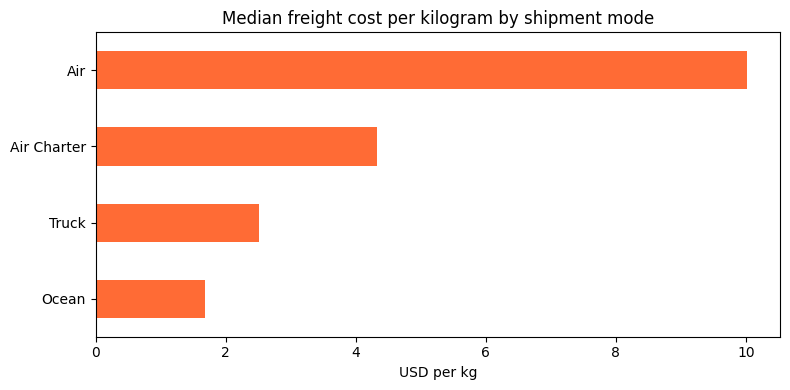

In [6]:
ax = mode_summary['median_freight_per_kg'].sort_values().plot.barh(figsize=(8,4), color='#ff6b35', title='Median freight cost per kilogram by shipment mode')
ax.set_xlabel('USD per kg'); ax.set_ylabel(''); plt.tight_layout(); plt.show()

### 5. Inspect the evaluated predictive model

In [7]:
payload = json.loads(MODEL.read_text())
model = payload['model']
pd.Series({k:v for k,v in model.items() if k not in ['drivers','method']})

training_rows    4929.000
test_rows        1233.000
r2_log              0.673
r2_dollars          0.474
mae_usd          6506.370
dtype: float64

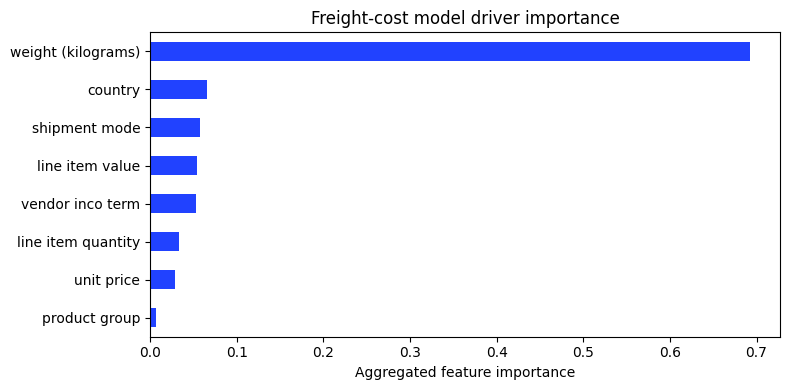

In [8]:
drivers = pd.DataFrame(model['drivers']).head(8).sort_values('importance')
ax = drivers.plot.barh(x='feature', y='importance', legend=False, figsize=(8,4), color='#2142ff', title='Freight-cost model driver importance')
ax.set_xlabel('Aggregated feature importance'); ax.set_ylabel(''); plt.tight_layout(); plt.show()

## Takeaways

1. Weight is the dominant predictive feature in the evaluated freight-cost model; lane, shipment mode, item value, and incoterm add meaningful context.
2. Missing freight and weight values are the largest data-quality constraint. Dashboard benchmarks therefore expose eligible sample size and never silently impute those fields.
3. Freight-per-kilogram and freight-as-percent-of-item-value answer different decisions and should not be merged into one generic “shipping cost” KPI.
4. The dashboard's AI layer is deterministic and evidence-bounded: it explains peer benchmarks, reason codes, and scenario deltas without inventing external market prices.